In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore, median_abs_deviation
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Set random seed for reproducibility
np.random.seed(42)

# 1. Data Acquisition

In [ ]:
# Load the dataset with the correct encoding and delimiter
df = pd.read_csv('small_businesses_enhanced1.csv', encoding='ISO-8859-1', delimiter=';')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

# Display the column names
print("\nColumn names:")
print(df.columns)

First 5 rows of the dataset:
               Business Name                            Business Description  \
0               Davidson LLC                        Balanced 24/7 throughput   
1                 Hill Group                   Networked background database   
2  Flowers, Benson and Mejia       Multi-lateral multi-tasking knowledgebase   
3  Phillips, Ho and Williams         Centralized context-sensitive moderator   
4                Johnson PLC  Programmable object-oriented Internet solution   

                                             Address         Industry  \
0              62377 Brown Camp, Jerryport, OH 80139  Food & Beverage   
1             4913 Cook Road, Gregorymouth, ME 19106          Fashion   
2    855 Fisher Canyon Apt. 341, Taylorton, NJ 19828           Health   
3  79465 Ramirez Mountains, North Maryport, MD 34794           Health   
4  83752 Christopher Way Apt. 894, North Joseph, ...           Health   

         Target Customer Customer Age Range        

# 2. Data Understanding

**2.1 Inspect Dataset Structure**

In [ ]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

# Check data types of each column
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

Dataset shape: (2960, 15)

Data types:
Business Name                object
Business Description         object
Address                      object
Industry                     object
Target Customer              object
Customer Age Range           object
Customer Country             object
Marketing Budget             object
Website                      object
Social Media                 object
Product Image URL            object
Product Description          object
Final Product Description    object
Company_Scrap_Data           object
Product_Scrap_Data           object
dtype: object

Missing values in each column:
Business Name                0
Business Description         0
Address                      0
Industry                     0
Target Customer              0
Customer Age Range           0
Customer Country             0
Marketing Budget             0
Website                      0
Social Media                 0
Product Image URL            0
Product Description          0
Fin

**# 2.2 Select Relevant Features**

In [ ]:
# Select only the relevant features for analysis
relevant_features = [
    'Industry', 'Target Customer', 'Customer Age Range',
    'Marketing Budget'
]

# Create a new DataFrame with only the relevant features
df_relevant = df[relevant_features]

# Display the first few rows of the relevant DataFrame
print("\nFirst 5 rows of the relevant DataFrame:")
print(df_relevant.head())


First 5 rows of the relevant DataFrame:
          Industry        Target Customer Customer Age Range Marketing Budget
0  Food & Beverage        Startups et PME          25-50 ans          45255 
1          Fashion  Jeunes professionnels          25-50 ans          41227 
2           Health  Jeunes professionnels          18-35 ans          30755 
3           Health  Jeunes professionnels          25-50 ans          35093 
4           Health        Startups et PME          18-35 ans          40319 


# 3. Data Preparation

**3.1 Handle Missing Values**

In [ ]:
# Drop rows with missing values
df_relevant = df_relevant.dropna()

# Verify that there are no missing values
print("\nMissing values after dropping:")
print(df_relevant.isnull().sum())


Missing values after dropping:
Industry              0
Target Customer       0
Customer Age Range    0
Marketing Budget      0
dtype: int64


**3.2 Clean the Marketing Budget Column**

In [ ]:
# Clean the Marketing Budget column
df_relevant['Marketing Budget'] = (
    df_relevant['Marketing Budget']
    .str.replace('', '', regex=False)  # Remove the Euro symbol
    .str.replace(',', '', regex=False)  # Remove commas (if any)
    .astype(float)  # Convert to numeric type
)

# Display the cleaned Marketing Budget column
print("\nCleaned Marketing Budget column:")
print(df_relevant['Marketing Budget'].head())


Cleaned Marketing Budget column:
0    45255.0
1    41227.0
2    30755.0
3    35093.0
4    40319.0
Name: Marketing Budget, dtype: float64


**3.3 Add Trends and Strategy Category Columns**

In [ ]:
import numpy as np
# Define mappings for trends based on industry, customer age, and country
trend_mappings = {
    "Food & Beverage": {
        "18-35 ans": [
            "Organic living, self-care",
            "Healthy snacks, plant-based diets",
            "Cold-pressed juices, superfoods"
        ],
        "25-50 ans": [
            "Home workouts",
            "Meal kits, premium beverages",
            "Wine tasting experiences, gourmet cooking"
        ]
    },
    "Fashion": {
        "18-35 ans": [
            "Athleisure, sustainability",
            "Streetwear, eco-friendly fashion",
            "Minimalist fashion, capsule wardrobes"
        ],
        "25-50 ans": [
            "Luxury fashion, timeless styles",
            "Pet wellness, eco-friendly products",
            "Experiential art, fashion shows"
        ]
    },
    "Health": {
        "18-35 ans": [
            "Mobile apps, remote work tools",
            "Fitness trackers, mental health apps",
            "Yoga, meditation retreats"
        ],
        "25-50 ans": [
            "Wellness retreats, personalized healthcare",
            "Sustainable travel, remote work locations",
            "Virtual events, hybrid events"
        ]
    },
    "Technology": {
        "18-35 ans": [
            "Gaming, AR/VR experiences",
            "Smart home devices, IoT",
            "Social media platforms, content creation tools"
        ],
        "25-50 ans": [
            "Smart home devices, productivity tools",
            "AI-driven solutions, automation",
            "Cybersecurity, data privacy"
        ]
    },
    "Education": {
        "18-35 ans": [
            "Online courses, skill development",
            "Coding bootcamps, tech certifications",
            "Language learning apps, study abroad programs"
        ],
        "25-50 ans": [
            "Professional certifications, executive education",
            "Leadership training, soft skills development",
            "Online MBA programs, career coaching"
        ]
    }
}
# Define mappings for strategy categories based on marketing budget and customer age
strategy_mappings = {
    "Low Budget": {
        "18-35 ans": "Social Media Marketing",
        "25-50 ans": "Email Marketing"
    },
    "Medium Budget": {
        "18-35 ans": "Content Marketing",
        "25-50 ans": "Search Engine Optimization (SEO)"
    },
    "High Budget": {
        "18-35 ans": "Pay-Per-Click (PPC) Advertising",
        "25-50 ans": "Event Marketing"
    }
}
def assign_trend(row):
    industry = row['Industry']
    age_range = row['Customer Age Range']

    # Get the trend based on the mappings
    if industry in trend_mappings:
        if age_range in trend_mappings[industry]:
            # Randomly select a trend from the list
            return np.random.choice(trend_mappings[industry][age_range])

    # If no mapping is found, return a random default trend
    return np.random.choice([
        "Home workouts", "Sustainability, local sourcing", "Online shopping, influencer marketing",
        "Mindfulness, online classes", "Organic living, self-care"
    ])
# Function to assign strategy based on marketing budget and customer age
def assign_strategy(row):
    budget = row['Marketing Budget']
    age_range = row['Customer Age Range']

    # Categorize budget into Low, Medium, or High
    if budget < 30000:
        budget_category = "Low Budget"
    elif 30000 <= budget <= 40000:
        budget_category = "Medium Budget"
    else:
        budget_category = "High Budget"

    # Get the strategy based on the budget category and age range
    if budget_category in strategy_mappings:
        if age_range in strategy_mappings[budget_category]:
            return strategy_mappings[budget_category][age_range]
    return np.random.choice([
        "Content Marketing", "Social Media Marketing", "Search Engine Optimization (SEO)"
    ])


# Apply the function to create the Trends column
df_relevant['Trends'] = df_relevant.apply(assign_trend, axis=1)
df_relevant['Strategy Category'] = df_relevant.apply(assign_strategy, axis=1)

# Display the first few rows of the updated DataFrame
print(df_relevant.head())
# Save the updated dataset to a new CSV file
df_relevant.to_csv('small_businesses_with_trends_and_strategy.csv', index=False)

print("Dataset saved successfully!")

          Industry        Target Customer Customer Age Range  \
0  Food & Beverage        Startups et PME          25-50 ans   
1          Fashion  Jeunes professionnels          25-50 ans   
2           Health  Jeunes professionnels          18-35 ans   
3           Health  Jeunes professionnels          25-50 ans   
4           Health        Startups et PME          18-35 ans   

   Marketing Budget                                     Trends  \
0           45255.0  Wine tasting experiences, gourmet cooking   
1           41227.0            Luxury fashion, timeless styles   
2           30755.0                  Yoga, meditation retreats   
3           35093.0              Virtual events, hybrid events   
4           40319.0             Mobile apps, remote work tools   

                  Strategy Category  
0                   Event Marketing  
1                   Event Marketing  
2                 Content Marketing  
3  Search Engine Optimization (SEO)  
4   Pay-Per-Click (PPC) Adve

**3.4 Encode Categorical Variables**

In [ ]:

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pickle
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# One-Hot Encoding for nominal categorical variables
df_relevant = pd.get_dummies(df_relevant, columns=['Industry', 'Target Customer'], drop_first=True)

strategy_encoder = LabelEncoder()
df_relevant['Customer Age Range'] = label_encoder.fit_transform(df_relevant['Customer Age Range'])

# Step 2: Encode the 'Strategy Category' column
df_relevant['Strategy Category'] = strategy_encoder.fit_transform(df_relevant['Strategy Category'])

# Step 3: Save the encoder for later use
with open('strategy_encoder.pkl', 'wb') as f:
    pickle.dump(strategy_encoder, f)

# Step 4: Display the DataFrame after encoding
print("\nDataFrame after encoding 'Strategy Category':")
print(df_relevant.head())

# Encode the 'Trends' column in-place
df_relevant['Trends'] = label_encoder.fit_transform(df_relevant['Trends'])

# Display the DataFrame after in-place encoding
print("\nDataFrame after in-place encoding of Strategy Category and Trends:")
print(df_relevant.head())


DataFrame after encoding 'Strategy Category':
   Customer Age Range  Marketing Budget  \
0                   2           45255.0   
1                   2           41227.0   
2                   0           30755.0   
3                   2           35093.0   
4                   0           40319.0   

                                      Trends  Strategy Category  \
0  Wine tasting experiences, gourmet cooking                  2   
1            Luxury fashion, timeless styles                  2   
2                  Yoga, meditation retreats                  0   
3              Virtual events, hybrid events                  4   
4             Mobile apps, remote work tools                  3   

   Industry_Fashion  Industry_Food & Beverage  Industry_Health  Industry_Tech  \
0             False                      True            False          False   
1              True                     False            False          False   
2             False                     False   

**3.5 Detect and Handle Outliers**

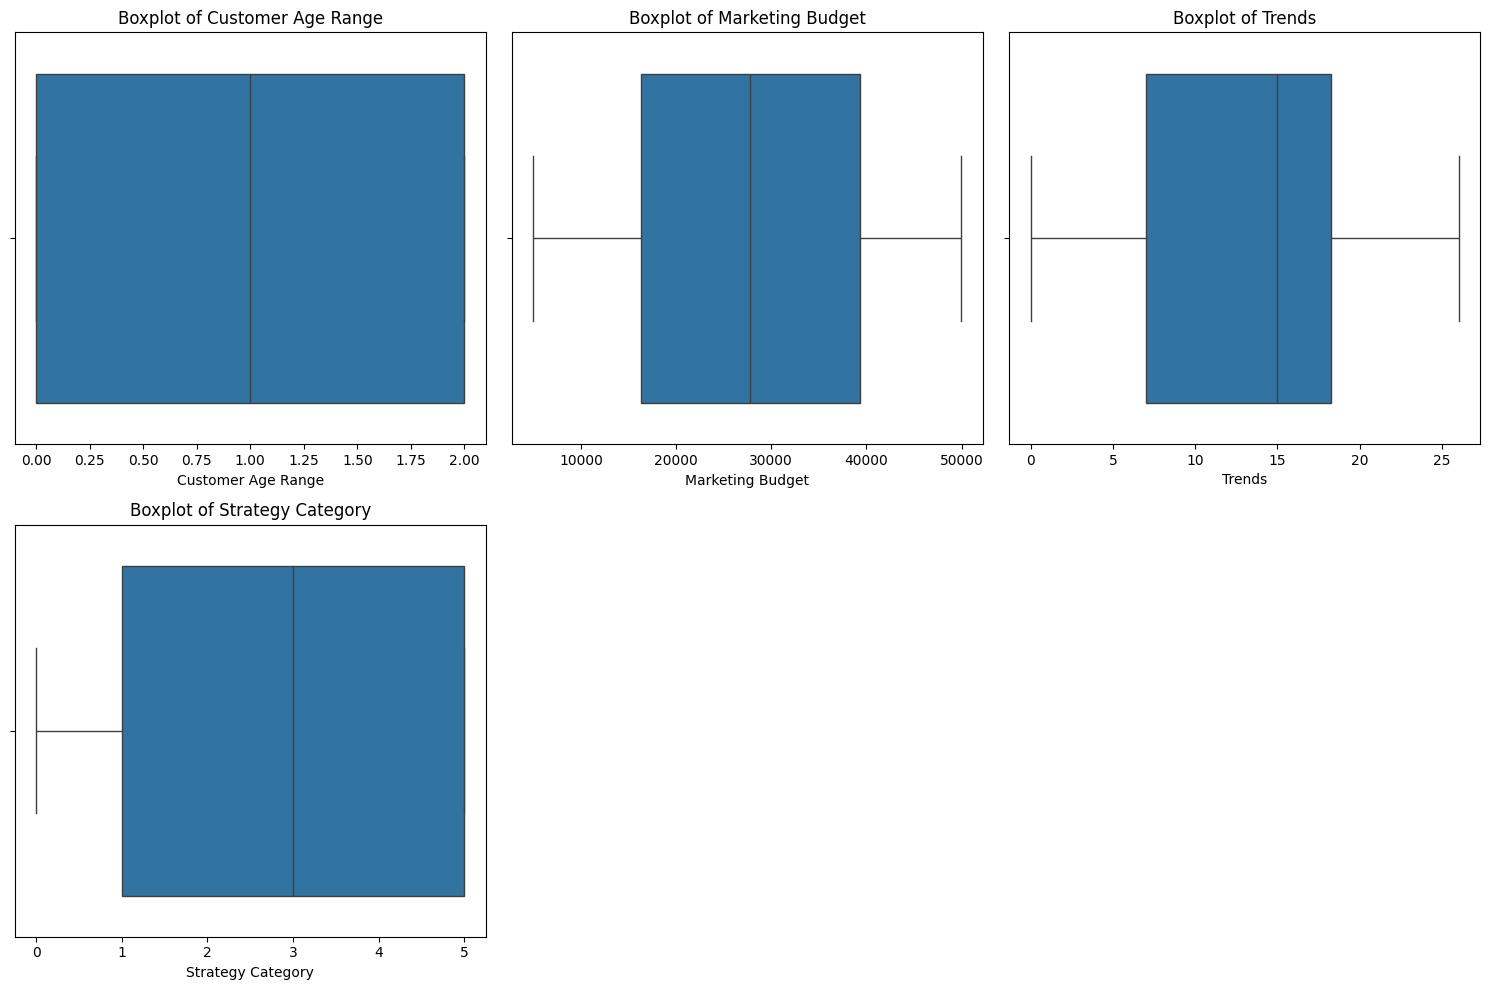

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplots
numerical_columns = df_relevant.select_dtypes(include=['float64', 'int64']).columns

# Create a boxplot for each numerical column
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)  # Adjust the grid size based on the number of columns
    sns.boxplot(x=df_relevant[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
plt.tight_layout()
plt.show()

**3.6 Balance the Dataset**

In [ ]:
from imblearn.over_sampling import SMOTE
# Balance the dataset (if applicable)
X = df_relevant.drop('Strategy Category', axis=1)  # Use 'Strategy Category' as the target
y = df_relevant['Strategy Category']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
df_relevant = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['Strategy Category'])], axis=1)

<ipython-input-22-b2d65af1a0d5>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_before, palette="viridis", ax=axes[0])
<ipython-input-22-b2d65af1a0d5>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_after, palette="viridis", ax=axes[1])


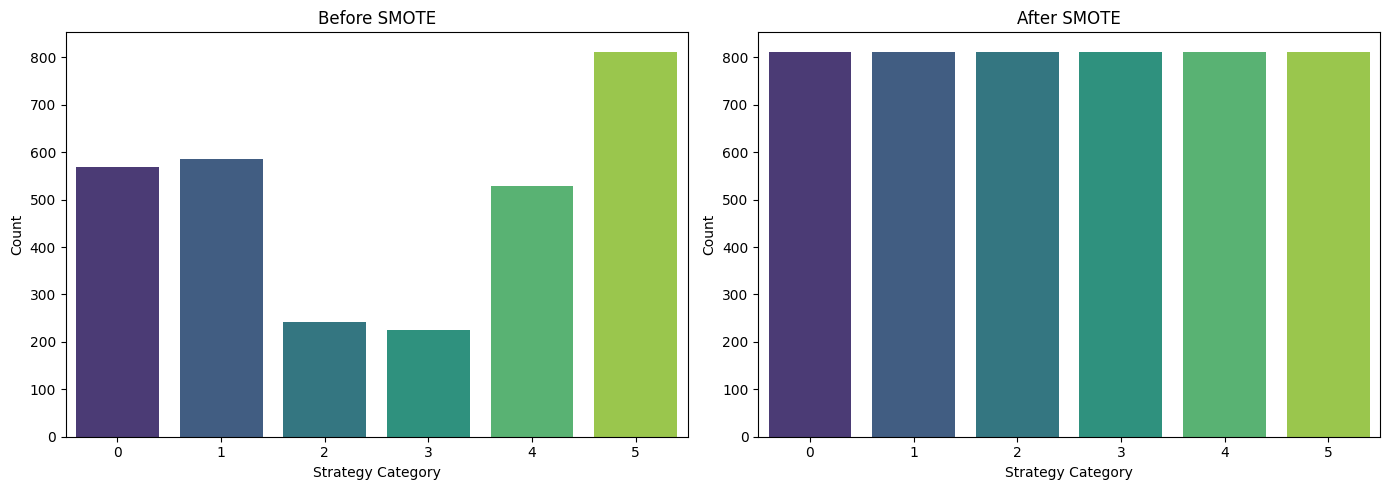

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot function for comparison
def plot_class_distribution(y_before, y_after, title_before="Before SMOTE", title_after="After SMOTE"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Before SMOTE
    sns.countplot(x=y_before, palette="viridis", ax=axes[0])
    axes[0].set_title(title_before)
    axes[0].set_xlabel("Strategy Category")
    axes[0].set_ylabel("Count")

    # After SMOTE
    sns.countplot(x=y_after, palette="viridis", ax=axes[1])
    axes[1].set_title(title_after)
    axes[1].set_xlabel("Strategy Category")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_class_distribution(y, y_resampled)

**3.8 Feature Scaling**

In [ ]:
# Standardize the features using StandardScaler
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Display the scaled features
print("\nScaled features:")
print(X_resampled_scaled[:5])


Scaled features:
[[ 1.10887185  1.00860758  1.8021789  -0.56944965  1.66022915 -0.62451122
  -0.59694844 -0.80821201  1.13460299]
 [ 1.10887185  0.70974    -0.68526642  1.75608152 -0.60232649 -0.62451122
  -0.59694844  1.23729911 -0.88136556]
 [-1.22529262 -0.06725634  1.95764423 -0.56944965 -0.60232649  1.60125225
  -0.59694844  1.23729911 -0.88136556]
 [ 1.10887185  0.25461246  1.49124823 -0.56944965 -0.60232649  1.60125225
  -0.59694844  1.23729911 -0.88136556]
 [-1.22529262  0.64236866 -0.06340509 -0.56944965 -0.60232649  1.60125225
  -0.59694844 -0.80821201  1.13460299]]


**3.9 Train-Test Split**

In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (3897, 9)
Testing set shape: (975, 9)


# 4- Modeling

**Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define the hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],   # Number of trees
    'max_depth': [None, 10, 20],      # Depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples to split
}

# Perform Grid Search
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Hyperparameters
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


**Compare Multiple Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(**grid_search.best_params_, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train & Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.5949
Random Forest Accuracy: 0.8564


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:38:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.8749


**Train the Best Model**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Initialize the XGBoost classifier with the best parameters
best_model = xgb.XGBClassifier(**grid_search.best_params_)

# Train the model
best_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:38:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, min_samples_split=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

# 5- Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Make Predictions
y_pred = best_model.predict(X_test)

# Print Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73       159
           1       1.00      1.00      1.00       162
           2       1.00      1.00      1.00       164
           3       1.00      0.99      1.00       162
           4       0.76      0.76      0.76       176
           5       0.74      0.78      0.76       152

    accuracy                           0.87       975
   macro avg       0.87      0.87      0.87       975
weighted avg       0.87      0.87      0.87       975

Confusion Matrix:
 [[114   0   0   0  22  23]
 [  0 162   0   0   0   0]
 [  0   0 164   0   0   0]
 [  1   0   0 161   0   0]
 [ 24   0   0   0 133  19]
 [ 15   0   0   0  19 118]]


**Test on New Data**

In [ ]:
import pickle

# Step 1: Load the saved encoder
with open('strategy_encoder.pkl', 'rb') as f:
    strategy_encoder = pickle.load(f)

# Step 2: Decode the predictions
predicted_categories = strategy_encoder.inverse_transform(y_pred)  # Decode the whole array

# Step 3: Test on a new sample and decode
new_sample = X_test.iloc[0].values.reshape(1, -1)  # Reshape for prediction
predicted_category = best_model.predict(new_sample)  # Predict the encoded category
predicted_category_decoded = strategy_encoder.inverse_transform(predicted_category)  # Decode to text

# Step 4: Print the result
print("Predicted Strategy Category for the new sample:", predicted_category_decoded[0])

Predicted Strategy Category for the new sample: Email Marketing
